# Radius ROC-AUC Panels for Three Experiments

This notebook builds one figure per experiment. Each figure has five panels, one for each session, and each panel plots ROC-AUC against radius (1, 2, 3, 4, 5 km).

Where the results come from:
- Experiment 2 reads `test_fold_evaluation.json` from each fold folder under `radius_dual_norwegain_only-unfreeze-backbone`.
- Experiment 3 reads `fold_summary.json` and uses `training_result.test_metrics.auc` from `aerosonic_to_norwegian_ex3`.
- Experiment 4 reads `fold_summary.json` and uses `training_result.test_metrics.auc` from `norwegian-aerosonic-and-augmented`.

The notebook also prints a source table so you can verify the exact file used for every radius/session point.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import FileLink, display

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Notebook-wide style configuration
FONT_FAMILY = "Times New Roman"
SHARED_FONT_SIZE = 35
BASE_FONT_SIZE = SHARED_FONT_SIZE
TITLE_FONT_SIZE = SHARED_FONT_SIZE
LEGEND_FONT_SIZE = SHARED_FONT_SIZE
LABEL_FONT_SIZE = SHARED_FONT_SIZE
TICK_FONT_SIZE = SHARED_FONT_SIZE

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": BASE_FONT_SIZE,
    "axes.titlesize": TITLE_FONT_SIZE,
    "axes.labelsize": LABEL_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,
})

In [3]:
# Select base drive automatically
BASE_HISTORY = Path("E:/history/sound-event-detection-aircrafts/final_runs") if Path("E:/").exists() else Path("D:/final_runs")

EXPERIMENTS = {
    "Experiment 2: radius_dual_norwegain_onlu-unfreeze-backbone": {
        "fold_leaf_dir": "norwegian_dual_radius_posneg",
        "radius_dirs": {
            1: BASE_HISTORY / "radius_dual_norwegain_only-unfreeze-backbone" / "20260525-110433Z" / "radius_dual_pos_1km_neg_10km_wnone",
            2: BASE_HISTORY / "radius_dual_norwegain_only-unfreeze-backbone" / "20260525-161827Z" / "radius_dual_pos_2km_neg_10km_wnone",
            3: BASE_HISTORY / "radius_dual_norwegain_only-unfreeze-backbone" / "20260522-172720Z" / "radius_dual_pos_3km_neg_10km_wnone",
            4: BASE_HISTORY / "radius_dual_norwegain_only-unfreeze-backbone" / "20260522-220158Z" / "radius_dual_pos_4km_neg_10km_wnone",
            5: BASE_HISTORY / "radius_dual_norwegain_only-unfreeze-backbone" / "20260523-012120Z" / "radius_dual_pos_5km_neg_10km_wnone",
        },
    },

    "Experiment 3: aerosonic_to_norwegian_ex3": {
        "fold_leaf_dir": "aero_only_to_norwegian",
        "radius_dirs": {
            1: BASE_HISTORY / "aerosonic_to_norwegian_ex3" / "20260525-090214Z" / "radius_dual_pos_1km_neg_10km_wnone",
            2: BASE_HISTORY / "aerosonic_to_norwegian_ex3" / "20260526-171718Z" / "radius_dual_pos_2km_neg_10km_wnone",
            3: BASE_HISTORY / "aerosonic_to_norwegian_ex3" / "20260525-195411Z" / "radius_dual_pos_3km_neg_10km_wnone",
            4: BASE_HISTORY / "aerosonic_to_norwegian_ex3" / "20260525-233358Z" / "radius_dual_pos_4km_neg_10km_wnone",
            5: BASE_HISTORY / "aerosonic_to_norwegian_ex3" / "20260526-032835Z" / "radius_dual_pos_5km_neg_10km_wnone",
        },
    },

    "Experiment 4: norwegain-and-aerosonic": {
        "fold_leaf_dir": "aero_plus_norwegian",
        "radius_dirs": {
            1: BASE_HISTORY / "norwegian-and-aerosonic" / "20260530-103154Z" / "radius_dual_pos_1km_neg_10km_wnone",
            2: BASE_HISTORY / "norwegian-and-aerosonic" / "20260529-203846Z" / "radius_dual_pos_2km_neg_10km_wnone",
            3: BASE_HISTORY / "norwegian-and-aerosonic" / "20260529-050941Z" / "radius_dual_pos_3km_neg_10km_wnone",
            4: BASE_HISTORY / "norwegian-and-aerosonic" / "20260528-105700Z" / "radius_dual_pos_4km_neg_10km_wnone",
            5: BASE_HISTORY / "norwegian-and-aerosonic" / "20260527-113056Z" / "radius_dual_pos_5km_neg_10km_wnone",
        },
    },

    "Experiment 5: norwegain-aerosonic-and-augmetned": {
        "fold_leaf_dir": "aero_plus_norwegian_with_aug",
        "radius_dirs": {
            1: BASE_HISTORY / "norwegian-aerosonic-and-augmented" / "20260526-070622Z" / "radius_dual_pos_1km_neg_10km_wnone",
            2: BASE_HISTORY / "norwegian-aerosonic-and-augmented" / "20260526-202559Z" / "radius_dual_pos_2km_neg_10km_wnone",
            3: BASE_HISTORY / "norwegian-aerosonic-and-augmented" / "20260522-004437Z" / "radius_dual_pos_3km_neg_10km_wnone",
            4: BASE_HISTORY / "norwegian-aerosonic-and-augmented" / "20260521-172853Z" / "radius_dual_pos_4km_neg_10km_wnone",
            5: BASE_HISTORY / "norwegian-aerosonic-and-augmented" / "20260521-160800Z" / "radius_dual_pos_5km_neg_10km_wnone",
        },
    },
}

EXPERIMENT_TO_TITLE = {
    "Experiment 2": "Experiment 2: Target-Domain Baseline",
    "Experiment 3": "Experiment 3: Cross-Domain Generalization",
    "Experiment 4": "Experiment 4: Combined-Dataset Training",
    "Experiment 5": "Experiment 5: Combined-Dataset Training with Augmentation",
}

FOLD_IDS = [0, 1, 2, 3, 4]
RADIUS_VALUES = [1, 2, 3, 4, 5]
METRIC_CANDIDATES = [
    "test_fold_evaluation.json",
    "fold_summary.json",
    "single_fold_result.json",
    Path("training") / "result.json",
]

In [4]:
def find_metric_file(fold_dir: Path) -> Path | None:
    for candidate in METRIC_CANDIDATES:
        candidate_path = fold_dir / candidate
        if candidate_path.exists():
            return candidate_path
    return None


def extract_auc(json_path: Path) -> float:
    payload = json.loads(json_path.read_text(encoding="utf-8"))

    candidate_paths = [
        ("metrics", "auc"),
        ("training_result", "test_metrics", "auc"),
        ("result", "metrics", "auc"),
        ("test_metrics", "auc"),
    ]

    for keys in candidate_paths:
        node = payload
        try:
            for key in keys:
                node = node[key]
            return float(node)
        except (KeyError, TypeError, ValueError):
            continue

    return np.nan


fold_to_session = {
    0: 3,
    1: 2,
    2: 4, 
    3: 1,
    4: 5
}


def load_experiment(experiment_name: str, spec: dict) -> pd.DataFrame:
    rows = []

    for radius_km in RADIUS_VALUES:
        radius_dir = spec["radius_dirs"][radius_km]
        fold_root = radius_dir / spec["fold_leaf_dir"]

        for fold_id in FOLD_IDS:
            fold_dir = fold_root / f"fold_{fold_id}_test_{fold_id}"
            session_id = fold_to_session[fold_id]  # Map fold_id to session_id

            # metric file (various possible files)
            metric_file = find_metric_file(fold_dir)
            auc = extract_auc(metric_file) if metric_file is not None else np.nan

            # extract fold status from fold_summary.json if present
            status = None
            summary_path = fold_dir / "fold_summary.json"
            if summary_path.exists():
                try:
                    summary = json.loads(summary_path.read_text(encoding="utf-8"))
                    status = summary.get("status") or summary.get("result", {}).get("status")
                except Exception:
                    status = None

            rows.append({
                "experiment": experiment_name,
                "session": session_id,
                "radius_km": radius_km,
                "roc_auc": auc,
                "status": status,
                "metric_file": str(metric_file) if metric_file is not None else None,
                "fold_dir": str(fold_dir),
            })

    return pd.DataFrame(rows)


all_results = pd.concat(
    [load_experiment(name, spec) for name, spec in EXPERIMENTS.items()],
    ignore_index=True,
)

display(all_results.sort_values(["experiment", "session", "radius_km"]))

,experiment,session,radius_km,roc_auc,status,metric_file,fold_dir
3,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,1,0.123611,completed,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
8,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,2,0.831340,completed,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
13,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,3,0.593755,completed,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
18,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,4,0.671519,completed,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
23,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,5,0.565997,completed,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
...,...,...,...,...,...,...,...
79,Experiment 5: norwegain-aerosonic-and-augmetned,5,1,0.227954,completed,D:\final_runs\norwegian-aerosonic-and-augmente...,D:\final_runs\norwegian-aerosonic-and-augmente...
84,Experiment 5: norwegain-aerosonic-and-augmetned,5,2,0.915202,completed,D:\final_runs\norwegian-aerosonic-and-augmente...,D:\final_runs\norwegian-aerosonic-and-augmente...
89,Experiment 5: norwegain-aerosonic-and-augmetned,5,3,0.504792,completed,D:\final_runs\norwegian-aerosonic-and-augmente...,D:\final_runs\norwegian-aerosonic-and-augmente...
94,Experiment 5: norwegain-aerosonic-and-augmetned,5,4,NaN,failed,D:\final_runs\norwegian-aerosonic-and-augmente...,D:\final_runs\norwegian-aerosonic-and-augmente...


In [5]:
# Display only rows where ROC-AUC is NaN to inspect missing results
nan_rows = all_results[all_results['roc_auc'].isna()].copy()
if len(nan_rows) == 0:
    print('No NaN ROC-AUC rows found')
else:
    display(nan_rows.sort_values(['experiment', 'session', 'radius_km']))
    print(f"Total NaN rows: {len(nan_rows)}")

# Also show unique metric files for NaN rows to inspect file locations
if len(nan_rows):
    print('\nUnique metric files for NaN rows:')
    print('\n'.join(sorted(filter(None, nan_rows['metric_file'].unique().tolist()))))

,experiment,session,radius_km,roc_auc,status,metric_file,fold_dir
1,Experiment 2: radius_dual_norwegain_onlu-unfre...,2,1,NaN,skipped,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
0,Experiment 2: radius_dual_norwegain_onlu-unfre...,3,1,NaN,skipped,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
5,Experiment 2: radius_dual_norwegain_onlu-unfre...,3,2,NaN,skipped,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
26,Experiment 3: aerosonic_to_norwegian_ex3,2,1,NaN,skipped,D:\final_runs\aerosonic_to_norwegian_ex3\20260...,D:\final_runs\aerosonic_to_norwegian_ex3\20260...
25,Experiment 3: aerosonic_to_norwegian_ex3,3,1,NaN,skipped,D:\final_runs\aerosonic_to_norwegian_ex3\20260...,D:\final_runs\aerosonic_to_norwegian_ex3\20260...
30,Experiment 3: aerosonic_to_norwegian_ex3,3,2,NaN,skipped,D:\final_runs\aerosonic_to_norwegian_ex3\20260...,D:\final_runs\aerosonic_to_norwegian_ex3\20260...
68,Experiment 4: norwegain-and-aerosonic,1,4,NaN,failed,D:\final_runs\norwegian-and-aerosonic\20260528...,D:\final_runs\norwegian-and-aerosonic\20260528...
51,Experiment 4: norwegain-and-aerosonic,2,1,NaN,skipped,D:\final_runs\norwegian-and-aerosonic\20260530...,D:\final_runs\norwegian-and-aerosonic\20260530...
61,Experiment 4: norwegain-and-aerosonic,2,3,NaN,failed,D:\final_runs\norwegian-and-aerosonic\20260529...,D:\final_runs\norwegian-and-aerosonic\20260529...
66,Experiment 4: norwegain-and-aerosonic,2,4,NaN,failed,D:\final_runs\norwegian-and-aerosonic\20260528...,D:\final_runs\norwegian-and-aerosonic\20260528...


Total NaN rows: 31

Unique metric files for NaN rows:
D:\final_runs\aerosonic_to_norwegian_ex3\20260525-090214Z\radius_dual_pos_1km_neg_10km_wnone\aero_only_to_norwegian\fold_0_test_0\fold_summary.json
D:\final_runs\aerosonic_to_norwegian_ex3\20260525-090214Z\radius_dual_pos_1km_neg_10km_wnone\aero_only_to_norwegian\fold_1_test_1\fold_summary.json
D:\final_runs\aerosonic_to_norwegian_ex3\20260526-171718Z\radius_dual_pos_2km_neg_10km_wnone\aero_only_to_norwegian\fold_0_test_0\fold_summary.json
D:\final_runs\norwegian-aerosonic-and-augmented\20260521-160800Z\radius_dual_pos_5km_neg_10km_wnone\aero_plus_norwegian_with_aug\fold_0_test_0\fold_summary.json
D:\final_runs\norwegian-aerosonic-and-augmented\20260521-160800Z\radius_dual_pos_5km_neg_10km_wnone\aero_plus_norwegian_with_aug\fold_1_test_1\fold_summary.json
D:\final_runs\norwegian-aerosonic-and-augmented\20260521-160800Z\radius_dual_pos_5km_neg_10km_wnone\aero_plus_norwegian_with_aug\fold_2_test_2\fold_summary.json
D:\final_runs\norwe

,experiment,session,radius_km,roc_auc,precision,recall,threshold,status,metric_file,fold_dir
3,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,1,0.123611,0.000000,0.000000,0.05,completed,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
8,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,2,0.831340,0.025768,1.000000,0.05,completed,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
13,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,3,0.593755,0.078846,0.953488,0.97,completed,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
18,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,4,0.671519,0.132718,1.000000,0.05,completed,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
23,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,5,0.565997,0.309547,1.000000,0.05,completed,D:\final_runs\radius_dual_norwegain_only-unfre...,D:\final_runs\radius_dual_norwegain_only-unfre...
...,...,...,...,...,...,...,...,...,...,...
79,Experiment 5: norwegain-aerosonic-and-augmetned,5,1,0.227954,0.203390,0.419907,0.99,completed,D:\final_runs\norwegian-aerosonic-and-augmente...,D:\final_runs\norwegian-aerosonic-and-augmente...
84,Experiment 5: norwegain-aerosonic-and-augmetned,5,2,0.915202,1.000000,0.158173,0.05,completed,D:\final_runs\norwegian-aerosonic-and-augmente...,D:\final_runs\norwegian-aerosonic-and-augmente...
89,Experiment 5: norwegain-aerosonic-and-augmetned,5,3,0.504792,1.000000,0.137156,0.05,completed,D:\final_runs\norwegian-aerosonic-and-augmente...,D:\final_runs\norwegian-aerosonic-and-augmente...
94,Experiment 5: norwegain-aerosonic-and-augmetned,5,4,NaN,NaN,NaN,NaN,failed,D:\final_runs\norwegian-aerosonic-and-augmente...,D:\final_runs\norwegian-aerosonic-and-augmente...


ROC-AUC table for merged comparison


1 km    2 km  \
experiment                                         session                   
Experiment 2: radius_dual_norwegain_onlu-unfree... 1        0.1236  0.8313   
                                                   2           NaN  0.8610   
                                                   3           NaN     NaN   
                                                   4        0.7834  0.5776   
                                                   5        0.0297  0.8911   
Experiment 3: aerosonic_to_norwegian_ex3           1        0.8182  0.8090   
                                                   2           NaN  0.3871   
                                                   3           NaN     NaN   
                                                   4        0.4129  0.4387   
                                                   5        0.8859  0.8644   
Experiment 4: norwegain-and-aerosonic              1        0.8116  0.8087   
                                                   2           NaN  0.5233   
                                                   3           NaN     NaN   
                                                   4        0.6582  0.5864   
                                                   5        0.0136  0.8112   
Experiment 5: norwegain-aerosonic-and-augmetned    1        0.1668  0.2598   
                                                   2           NaN  0.3214   
                                                   3           NaN     NaN   
                                                   4        0.4290  0.3355   
                                                   5        0.2280  0.9152   

                                                              3 km    4 km  \
experiment                                         session                   
Experiment 2: radius_dual_norwegain_onlu-unfree... 1        0.5938  0.6715   
                                                   2        0.3086  0.4437   
                                                   3        0.5280  0.1719   
                                                   4        0.4238  0.5702   
                                                   5        0.8176  0.6978   
Experiment 3: aerosonic_to_norwegian_ex3           1        0.5957  0.4777   
                                                   2        0.3345  0.3949   
                                                   3        0.5879  0.0768   
                                                   4        0.5243  0.5002   
                                                   5        0.3218  0.7273   
Experiment 4: norwegain-and-aerosonic              1        0.7503     NaN   
                                                   2           NaN     NaN   
                                                   3        0.3996     NaN   
                                                   4           NaN     NaN   
                                                   5        0.1050     NaN   
Experiment 5: norwegain-aerosonic-and-augmetned    1           NaN     NaN   
                                                   2        0.6865     NaN   
                                                   3        0.2139     NaN   
                                                   4        0.3637     NaN   
                                                   5        0.5048     NaN   

                                                              5 km  \
experiment                                         session           
Experiment 2: radius_dual_norwegain_onlu-unfree... 1        0.5660   
                                                   2        0.4989   
                                                   3        0.6366   
                                                   4        0.4709   
                                                   5        0.2352   
Experiment 3: aerosonic_to_norwegian_ex3           1        0.5528   
                                                   2        0.4533  

LaTeX code:
\begin{tabular}{llrrrrrll}
\toprule
 &  & 1 km & 2 km & 3 km & 4 km & 5 km & Best radius & Best ROC-AUC \\
experiment & session &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{Experiment 2: radius_dual_norwegain_onlu-unfreeze-backbone} & 1 & 0.123600 & 0.831300 & 0.593800 & 0.671500 & 0.566000 & 2 km & 0.8313 \\
 & 2 & — & 0.861000 & 0.308600 & 0.443700 & 0.498900 & 2 km & 0.8610 \\
 & 3 & — & — & 0.528000 & 0.171900 & 0.636600 & 5 km & 0.6366 \\
 & 4 & 0.783400 & 0.577600 & 0.423800 & 0.570200 & 0.470900 & 1 km & 0.7834 \\
 & 5 & 0.029700 & 0.891100 & 0.817600 & 0.697800 & 0.235200 & 2 km & 0.8911 \\
\cline{1-9}
\multirow[t]{5}{*}{Experiment 3: aerosonic_to_norwegian_ex3} & 1 & 0.818200 & 0.809000 & 0.595700 & 0.477700 & 0.552800 & 1 km & 0.8182 \\
 & 2 & — & 0.387100 & 0.334500 & 0.394900 & 0.453300 & 5 km & 0.4533 \\
 & 3 & — & — & 0.587900 & 0.076800 & 0.386700 & 3 km & 0.5879 \\
 & 4 & 0.412900 & 0.438700 & 0.524300 & 0.500200 & 0.485700 & 3 km & 0.5243 \\
 & 5 & 0

c:\Users\imborhau\Documents\sound-event-detection-aircrafts\notebooks\outputs\experiment_radius_roc_auc_panels\merged_experiment_comparison.pdf

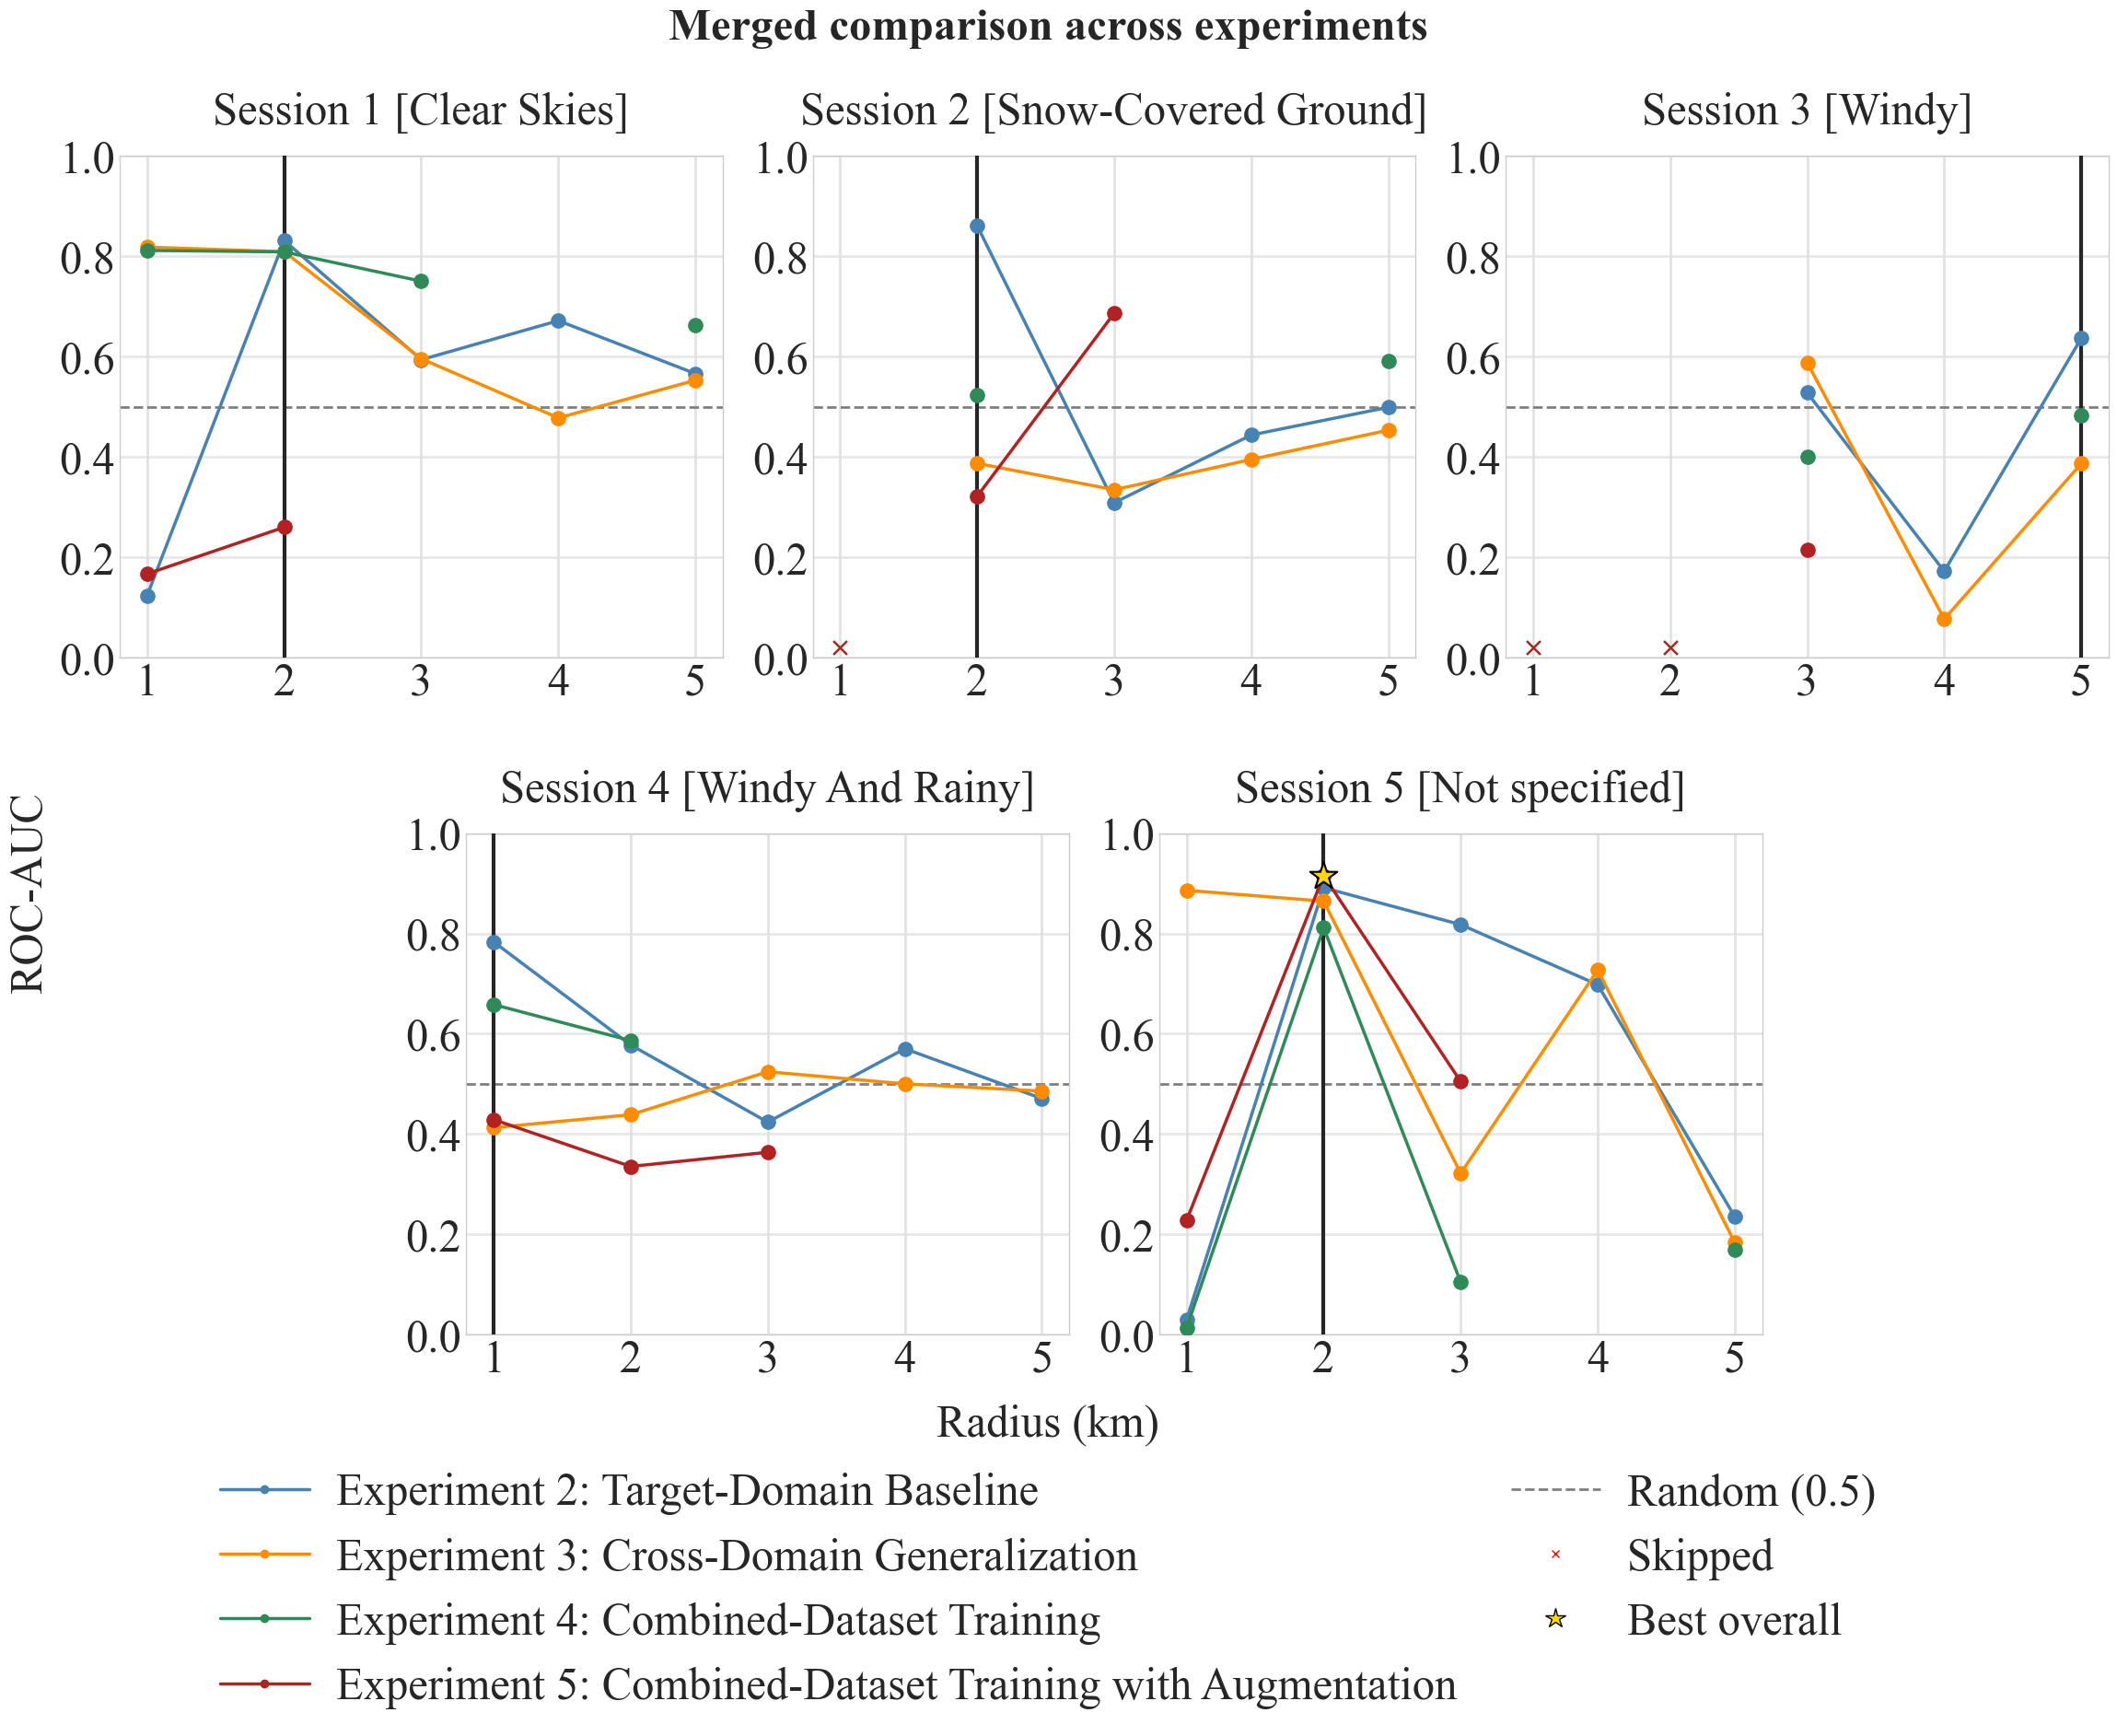

Metric summary table for Experiment 2: radius_dual_norwegain_onlu-unfreeze-backbone


,1 km,2 km,3 km,4 km,5 km
Metric,,,,,
ROC-AUC,0.3122 ± 0.3353,0.7903 ± 0.1246,0.5344 ± 0.1714,0.5110 ± 0.1917,0.4815 ± 0.1359
Precision,0.0780 ± 0.1050,0.1623 ± 0.2274,0.1957 ± 0.2783,0.2663 ± 0.2756,0.4502 ± 0.2229
Recall,0.1942 ± 0.2680,0.9997 ± 0.0005,0.9692 ± 0.0421,0.9988 ± 0.0017,0.9983 ± 0.0035


LaTeX code:
\begin{tabular}{llllll}
\toprule
 & 1 km & 2 km & 3 km & 4 km & 5 km \\
Metric &  &  &  &  &  \\
\midrule
ROC-AUC & 0.3122 \pm 0.3353 & 0.7903 \pm 0.1246 & 0.5344 \pm 0.1714 & 0.5110 \pm 0.1917 & 0.4815 \pm 0.1359 \\
Precision & 0.0780 \pm 0.1050 & 0.1623 \pm 0.2274 & 0.1957 \pm 0.2783 & 0.2663 \pm 0.2756 & 0.4502 \pm 0.2229 \\
Recall & 0.1942 \pm 0.2680 & 0.9997 \pm 0.0005 & 0.9692 \pm 0.0421 & 0.9988 \pm 0.0017 & 0.9983 \pm 0.0035 \\
\bottomrule
\end{tabular}

Best-radius table for Experiment 2: radius_dual_norwegain_onlu-unfreeze-backbone


,Best Radius,Threshold,ROC-AUC,Precision,Recall
Session,,,,,
1,2 km,0.0500,0.8313,0.0258,1.0000
2,2 km,0.9900,0.8610,0.0496,1.0000
3,5 km,0.0500,0.6366,0.3852,1.0000
4,1 km,0.6500,0.7834,0.0076,0.5732
5,2 km,0.9600,0.8911,0.5556,0.9989


LaTeX code:
\begin{tabular}{llllll}
\toprule
 & Best Radius & Threshold & ROC-AUC & Precision & Recall \\
Session &  &  &  &  &  \\
\midrule
1 & 2 km & 0.0500 & 0.8313 & 0.0258 & 1.0000 \\
2 & 2 km & 0.9900 & 0.8610 & 0.0496 & 1.0000 \\
3 & 5 km & 0.0500 & 0.6366 & 0.3852 & 1.0000 \\
4 & 1 km & 0.6500 & 0.7834 & 0.0076 & 0.5732 \\
5 & 2 km & 0.9600 & 0.8911 & 0.5556 & 0.9989 \\
\bottomrule
\end{tabular}

Session-by-radius ROC-AUC table for Experiment 2: radius_dual_norwegain_onlu-unfreeze-backbone


,1 km,2 km,3 km,4 km,5 km
Session,,,,,
1,0.1236,0.8313,0.5938,0.6715,0.5660
2,—,0.8610,0.3086,0.4437,0.4989
3,—,—,0.5280,0.1719,0.6366
4,0.7834,0.5776,0.4238,0.5702,0.4709
5,0.0297,0.8911,0.8176,0.6978,0.2352


LaTeX code:
\begin{tabular}{llllll}
\toprule
 & 1 km & 2 km & 3 km & 4 km & 5 km \\
Session &  &  &  &  &  \\
\midrule
1 & 0.1236 & 0.8313 & 0.5938 & 0.6715 & 0.5660 \\
2 & — & 0.8610 & 0.3086 & 0.4437 & 0.4989 \\
3 & — & — & 0.5280 & 0.1719 & 0.6366 \\
4 & 0.7834 & 0.5776 & 0.4238 & 0.5702 & 0.4709 \\
5 & 0.0297 & 0.8911 & 0.8176 & 0.6978 & 0.2352 \\
\bottomrule
\end{tabular}

Session 1 - valid rows: 5, skipped rows: 0, missing rows: 0
Session 2 - valid rows: 4, skipped rows: 1, missing rows: 0
Session 3 - valid rows: 3, skipped rows: 2, missing rows: 0
Session 4 - valid rows: 5, skipped rows: 0, missing rows: 0
Session 5 - valid rows: 5, skipped rows: 0, missing rows: 0


c:\Users\imborhau\Documents\sound-event-detection-aircrafts\notebooks\outputs\experiment_radius_roc_auc_panels\Experiment_2_radius_dual_norwegain_onlu-unfreeze-backbone.pdf

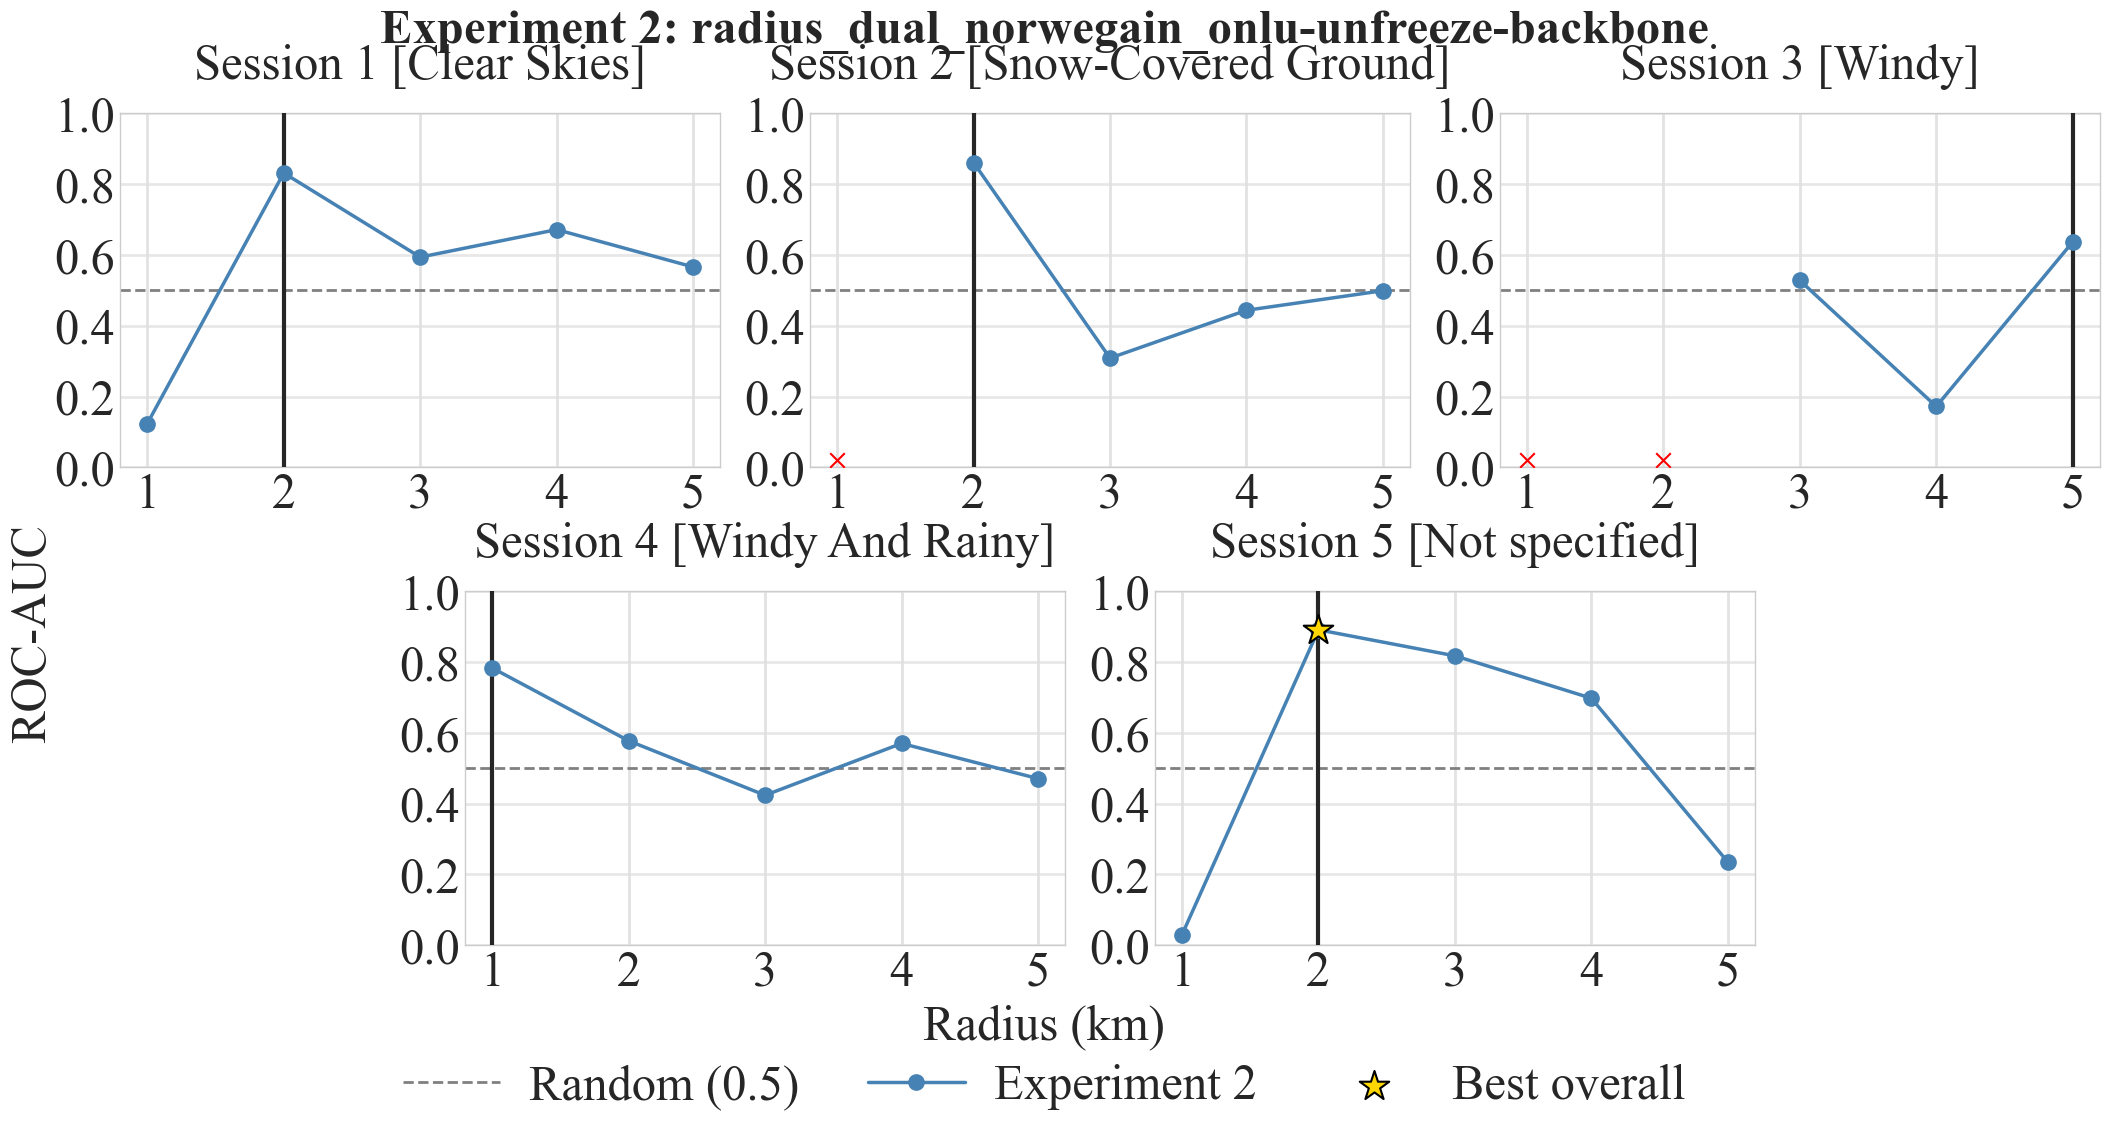

Metric summary table for Experiment 3: aerosonic_to_norwegian_ex3


,1 km,2 km,3 km,4 km,5 km
Metric,,,,,
ROC-AUC,0.7057 ± 0.2089,0.6248 ± 0.2136,0.4728 ± 0.1208,0.4354 ± 0.2104,0.4124 ± 0.1264
Precision,0.3366 ± 0.4691,0.2797 ± 0.4160,0.2264 ± 0.3864,0.3061 ± 0.3679,0.4925 ± 0.2892
Recall,0.3389 ± 0.2927,0.5979 ± 0.3991,0.0981 ± 0.0560,0.3798 ± 0.4426,0.0347 ± 0.0467


LaTeX code:
\begin{tabular}{llllll}
\toprule
 & 1 km & 2 km & 3 km & 4 km & 5 km \\
Metric &  &  &  &  &  \\
\midrule
ROC-AUC & 0.7057 \pm 0.2089 & 0.6248 \pm 0.2136 & 0.4728 \pm 0.1208 & 0.4354 \pm 0.2104 & 0.4124 \pm 0.1264 \\
Precision & 0.3366 \pm 0.4691 & 0.2797 \pm 0.4160 & 0.2264 \pm 0.3864 & 0.3061 \pm 0.3679 & 0.4925 \pm 0.2892 \\
Recall & 0.3389 \pm 0.2927 & 0.5979 \pm 0.3991 & 0.0981 \pm 0.0560 & 0.3798 \pm 0.4426 & 0.0347 \pm 0.0467 \\
\bottomrule
\end{tabular}

Best-radius table for Experiment 3: aerosonic_to_norwegian_ex3


,Best Radius,Threshold,ROC-AUC,Precision,Recall
Session,,,,,
1,1 km,0.0500,0.8182,0.0097,0.7143
2,5 km,0.0500,0.4533,0.3910,0.0037
3,3 km,0.0500,0.5879,0.0009,0.1579
4,3 km,0.0500,0.5243,0.0000,0.0000
5,1 km,0.0500,0.8859,1.0000,0.3025


LaTeX code:
\begin{tabular}{llllll}
\toprule
 & Best Radius & Threshold & ROC-AUC & Precision & Recall \\
Session &  &  &  &  &  \\
\midrule
1 & 1 km & 0.0500 & 0.8182 & 0.0097 & 0.7143 \\
2 & 5 km & 0.0500 & 0.4533 & 0.3910 & 0.0037 \\
3 & 3 km & 0.0500 & 0.5879 & 0.0009 & 0.1579 \\
4 & 3 km & 0.0500 & 0.5243 & 0.0000 & 0.0000 \\
5 & 1 km & 0.0500 & 0.8859 & 1.0000 & 0.3025 \\
\bottomrule
\end{tabular}

Session-by-radius ROC-AUC table for Experiment 3: aerosonic_to_norwegian_ex3


,1 km,2 km,3 km,4 km,5 km
Session,,,,,
1,0.8182,0.8090,0.5957,0.4777,0.5528
2,—,0.3871,0.3345,0.3949,0.4533
3,—,—,0.5879,0.0768,0.3867
4,0.4129,0.4387,0.5243,0.5002,0.4857
5,0.8859,0.8644,0.3218,0.7273,0.1833


LaTeX code:
\begin{tabular}{llllll}
\toprule
 & 1 km & 2 km & 3 km & 4 km & 5 km \\
Session &  &  &  &  &  \\
\midrule
1 & 0.8182 & 0.8090 & 0.5957 & 0.4777 & 0.5528 \\
2 & — & 0.3871 & 0.3345 & 0.3949 & 0.4533 \\
3 & — & — & 0.5879 & 0.0768 & 0.3867 \\
4 & 0.4129 & 0.4387 & 0.5243 & 0.5002 & 0.4857 \\
5 & 0.8859 & 0.8644 & 0.3218 & 0.7273 & 0.1833 \\
\bottomrule
\end{tabular}

Session 1 - valid rows: 5, skipped rows: 0, missing rows: 0
Session 2 - valid rows: 4, skipped rows: 1, missing rows: 0
Session 3 - valid rows: 3, skipped rows: 2, missing rows: 0
Session 4 - valid rows: 5, skipped rows: 0, missing rows: 0
Session 5 - valid rows: 5, skipped rows: 0, missing rows: 0


c:\Users\imborhau\Documents\sound-event-detection-aircrafts\notebooks\outputs\experiment_radius_roc_auc_panels\Experiment_3_aerosonic_to_norwegian_ex3.pdf

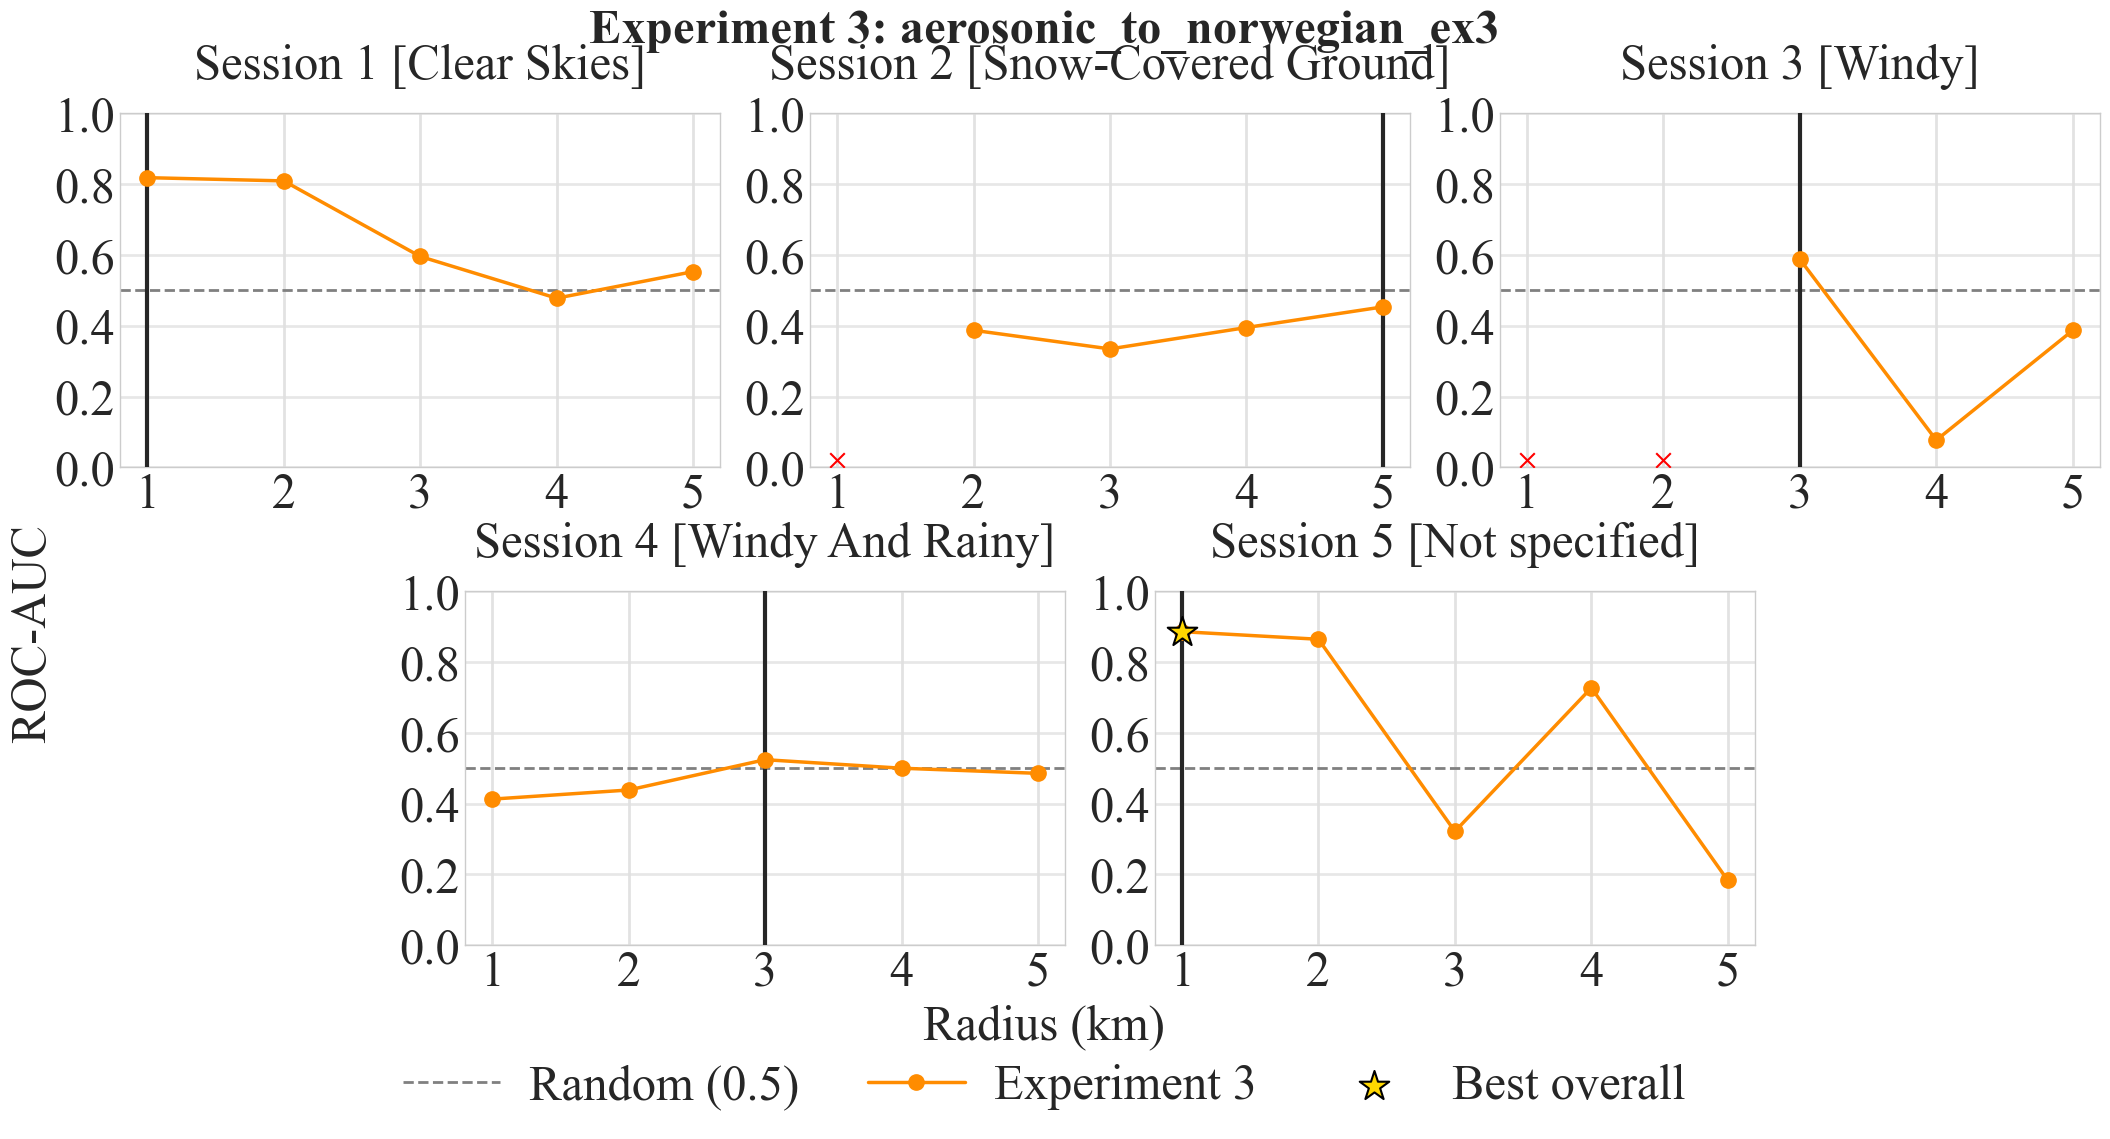

Metric summary table for Experiment 4: norwegain-and-aerosonic


,1 km,2 km,3 km,4 km,5 km
Metric,,,,,
ROC-AUC,0.4945 ± 0.3458,0.6824 ± 0.1295,0.4183 ± 0.2638,—,0.4764 ± 0.1885
Precision,0.0135 ± 0.0066,0.2214 ± 0.2975,0.2260 ± 0.2537,—,0.5355 ± 0.1678
Recall,0.4034 ± 0.4266,0.6372 ± 0.3276,0.7803 ± 0.2463,—,0.9209 ± 0.0596


LaTeX code:
\begin{tabular}{llllll}
\toprule
 & 1 km & 2 km & 3 km & 4 km & 5 km \\
Metric &  &  &  &  &  \\
\midrule
ROC-AUC & 0.4945 \pm 0.3458 & 0.6824 \pm 0.1295 & 0.4183 \pm 0.2638 & — & 0.4764 \pm 0.1885 \\
Precision & 0.0135 \pm 0.0066 & 0.2214 \pm 0.2975 & 0.2260 \pm 0.2537 & — & 0.5355 \pm 0.1678 \\
Recall & 0.4034 \pm 0.4266 & 0.6372 \pm 0.3276 & 0.7803 \pm 0.2463 & — & 0.9209 \pm 0.0596 \\
\bottomrule
\end{tabular}

Best-radius table for Experiment 4: norwegain-and-aerosonic


,Best Radius,Threshold,ROC-AUC,Precision,Recall
Session,,,,,
1,1 km,0.9900,0.8116,0.0043,1.0000
2,5 km,0.0500,0.5913,0.5698,0.9359
3,5 km,0.0500,0.4831,0.3852,1.0000
4,1 km,0.9900,0.6582,0.0165,0.1829
5,2 km,0.9900,0.8112,0.7365,0.7799


LaTeX code:
\begin{tabular}{llllll}
\toprule
 & Best Radius & Threshold & ROC-AUC & Precision & Recall \\
Session &  &  &  &  &  \\
\midrule
1 & 1 km & 0.9900 & 0.8116 & 0.0043 & 1.0000 \\
2 & 5 km & 0.0500 & 0.5913 & 0.5698 & 0.9359 \\
3 & 5 km & 0.0500 & 0.4831 & 0.3852 & 1.0000 \\
4 & 1 km & 0.9900 & 0.6582 & 0.0165 & 0.1829 \\
5 & 2 km & 0.9900 & 0.8112 & 0.7365 & 0.7799 \\
\bottomrule
\end{tabular}

Session-by-radius ROC-AUC table for Experiment 4: norwegain-and-aerosonic


,1 km,2 km,3 km,4 km,5 km
Session,,,,,
1,0.8116,0.8087,0.7503,—,0.6621
2,—,0.5233,—,—,0.5913
3,—,—,0.3996,—,0.4831
4,0.6582,0.5864,—,—,—
5,0.0136,0.8112,0.1050,—,0.1692


LaTeX code:
\begin{tabular}{llllll}
\toprule
 & 1 km & 2 km & 3 km & 4 km & 5 km \\
Session &  &  &  &  &  \\
\midrule
1 & 0.8116 & 0.8087 & 0.7503 & — & 0.6621 \\
2 & — & 0.5233 & — & — & 0.5913 \\
3 & — & — & 0.3996 & — & 0.4831 \\
4 & 0.6582 & 0.5864 & — & — & — \\
5 & 0.0136 & 0.8112 & 0.1050 & — & 0.1692 \\
\bottomrule
\end{tabular}

Session 1 - valid rows: 4, skipped rows: 0, missing rows: 1
Session 2 - valid rows: 2, skipped rows: 1, missing rows: 2
Session 3 - valid rows: 2, skipped rows: 2, missing rows: 1
Session 4 - valid rows: 2, skipped rows: 0, missing rows: 3
Session 5 - valid rows: 4, skipped rows: 0, missing rows: 1


c:\Users\imborhau\Documents\sound-event-detection-aircrafts\notebooks\outputs\experiment_radius_roc_auc_panels\Experiment_4_norwegain-and-aerosonic.pdf

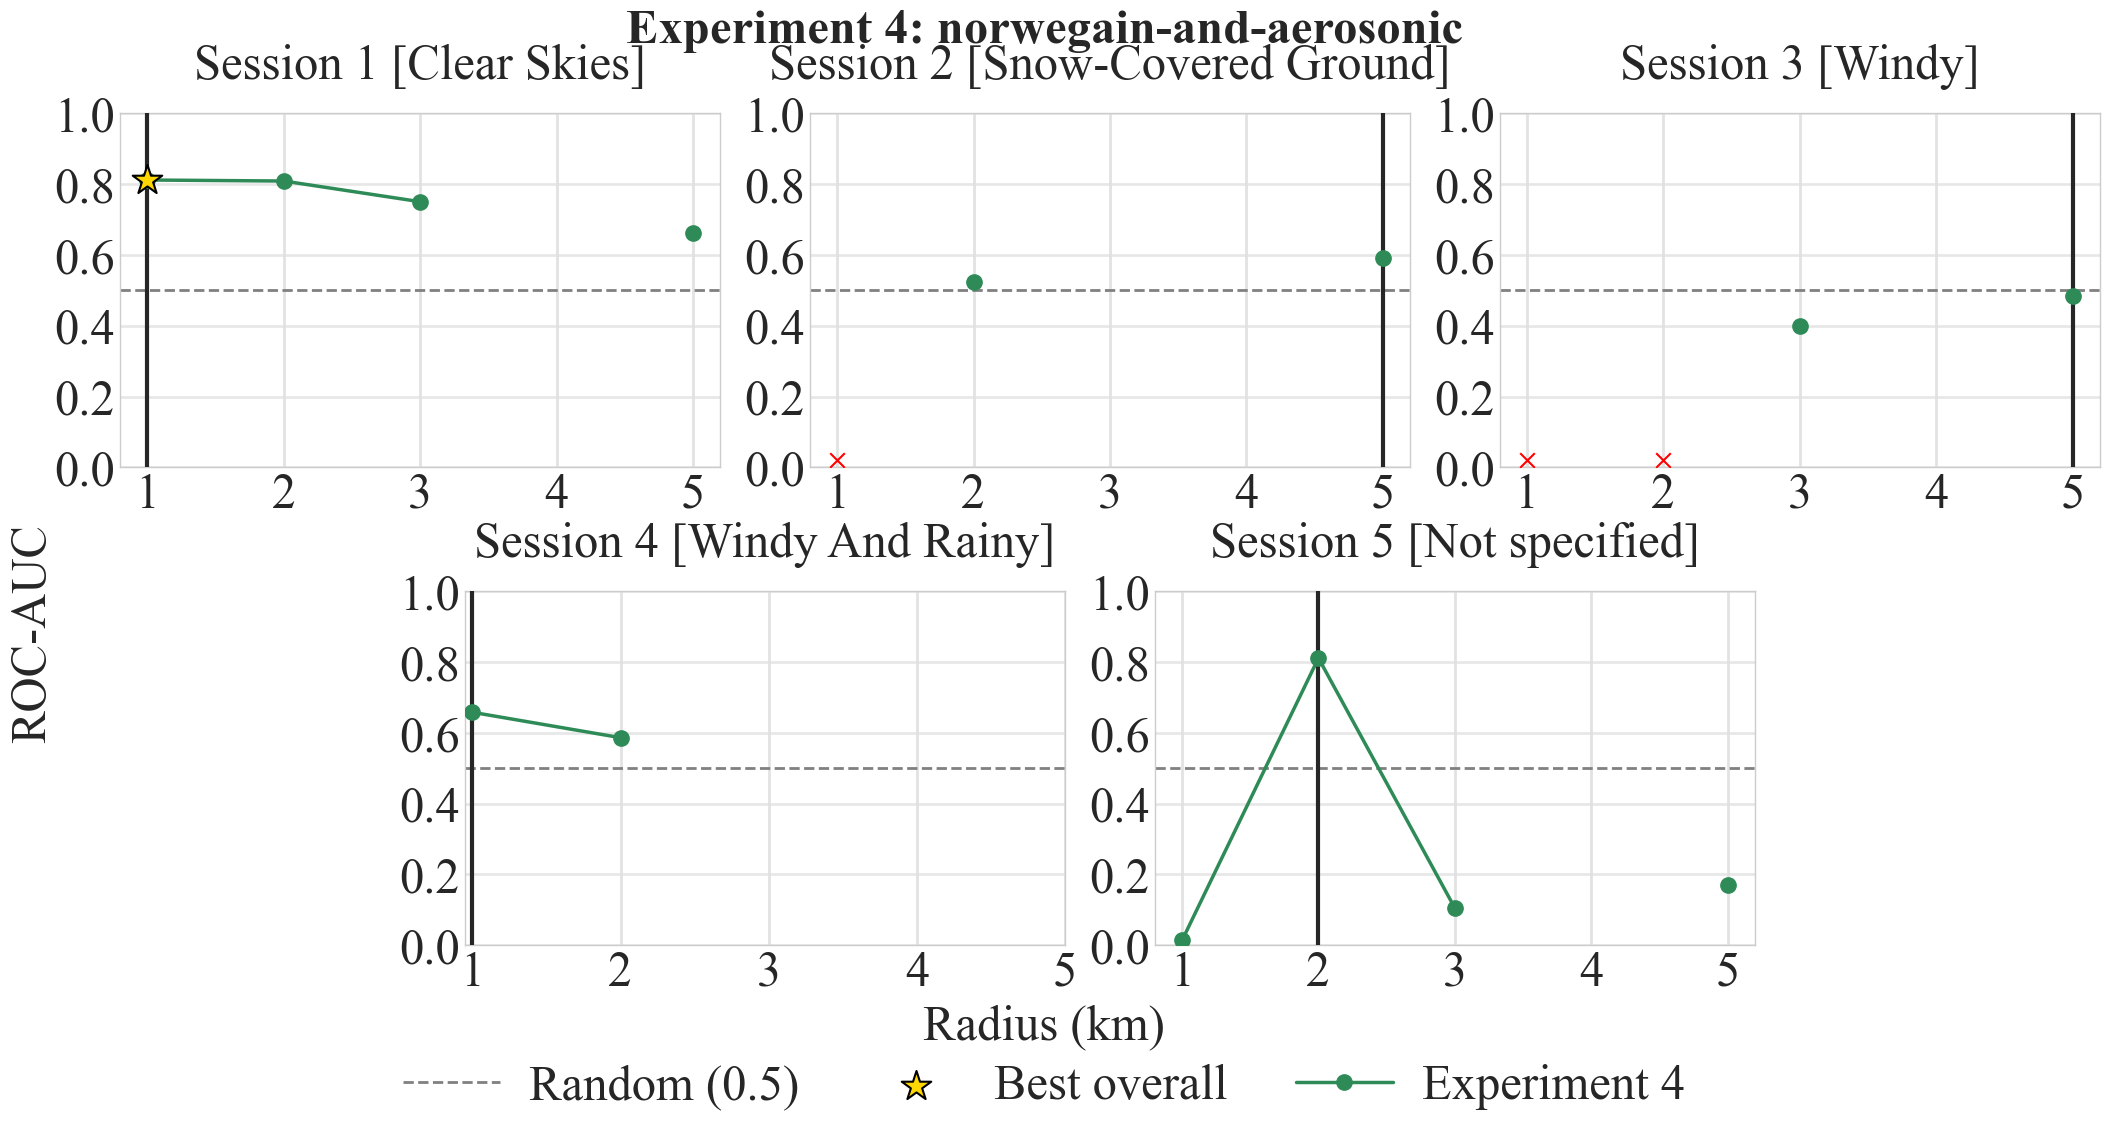

Metric summary table for Experiment 5: norwegain-aerosonic-and-augmetned


,1 km,2 km,3 km,4 km,5 km
Metric,,,,,
ROC-AUC,0.2746 ± 0.1120,0.4580 ± 0.2655,0.4422 ± 0.1746,—,—
Precision,0.0686 ± 0.0953,0.3378 ± 0.3952,0.3986 ± 0.4028,—,—
Recall,0.4733 ± 0.4100,0.0517 ± 0.0633,0.3021 ± 0.4045,—,—


LaTeX code:
\begin{tabular}{llllll}
\toprule
 & 1 km & 2 km & 3 km & 4 km & 5 km \\
Metric &  &  &  &  &  \\
\midrule
ROC-AUC & 0.2746 \pm 0.1120 & 0.4580 \pm 0.2655 & 0.4422 \pm 0.1746 & — & — \\
Precision & 0.0686 \pm 0.0953 & 0.3378 \pm 0.3952 & 0.3986 \pm 0.4028 & — & — \\
Recall & 0.4733 \pm 0.4100 & 0.0517 \pm 0.0633 & 0.3021 \pm 0.4045 & — & — \\
\bottomrule
\end{tabular}

Best-radius table for Experiment 5: norwegain-aerosonic-and-augmetned


,Best Radius,Threshold,ROC-AUC,Precision,Recall
Session,,,,,
1,2 km,0.0500,0.2598,0.0656,0.0059
2,3 km,0.0500,0.6865,0.5294,0.0198
3,3 km,0.0500,0.2139,0.0009,0.0526
4,1 km,0.2600,0.4290,0.0000,0.0000
5,2 km,0.0500,0.9152,1.0000,0.1582


LaTeX code:
\begin{tabular}{llllll}
\toprule
 & Best Radius & Threshold & ROC-AUC & Precision & Recall \\
Session &  &  &  &  &  \\
\midrule
1 & 2 km & 0.0500 & 0.2598 & 0.0656 & 0.0059 \\
2 & 3 km & 0.0500 & 0.6865 & 0.5294 & 0.0198 \\
3 & 3 km & 0.0500 & 0.2139 & 0.0009 & 0.0526 \\
4 & 1 km & 0.2600 & 0.4290 & 0.0000 & 0.0000 \\
5 & 2 km & 0.0500 & 0.9152 & 1.0000 & 0.1582 \\
\bottomrule
\end{tabular}

Session-by-radius ROC-AUC table for Experiment 5: norwegain-aerosonic-and-augmetned


,1 km,2 km,3 km,4 km,5 km
Session,,,,,
1,0.1668,0.2598,—,—,—
2,—,0.3214,0.6865,—,—
3,—,—,0.2139,—,—
4,0.4290,0.3355,0.3637,—,—
5,0.2280,0.9152,0.5048,—,—


LaTeX code:
\begin{tabular}{llllll}
\toprule
 & 1 km & 2 km & 3 km & 4 km & 5 km \\
Session &  &  &  &  &  \\
\midrule
1 & 0.1668 & 0.2598 & — & — & — \\
2 & — & 0.3214 & 0.6865 & — & — \\
3 & — & — & 0.2139 & — & — \\
4 & 0.4290 & 0.3355 & 0.3637 & — & — \\
5 & 0.2280 & 0.9152 & 0.5048 & — & — \\
\bottomrule
\end{tabular}

Session 1 - valid rows: 2, skipped rows: 0, missing rows: 3
Session 2 - valid rows: 2, skipped rows: 1, missing rows: 2
Session 3 - valid rows: 1, skipped rows: 2, missing rows: 2
Session 4 - valid rows: 3, skipped rows: 0, missing rows: 2
Session 5 - valid rows: 3, skipped rows: 0, missing rows: 2


c:\Users\imborhau\Documents\sound-event-detection-aircrafts\notebooks\outputs\experiment_radius_roc_auc_panels\Experiment_5_norwegain-aerosonic-and-augmetned.pdf

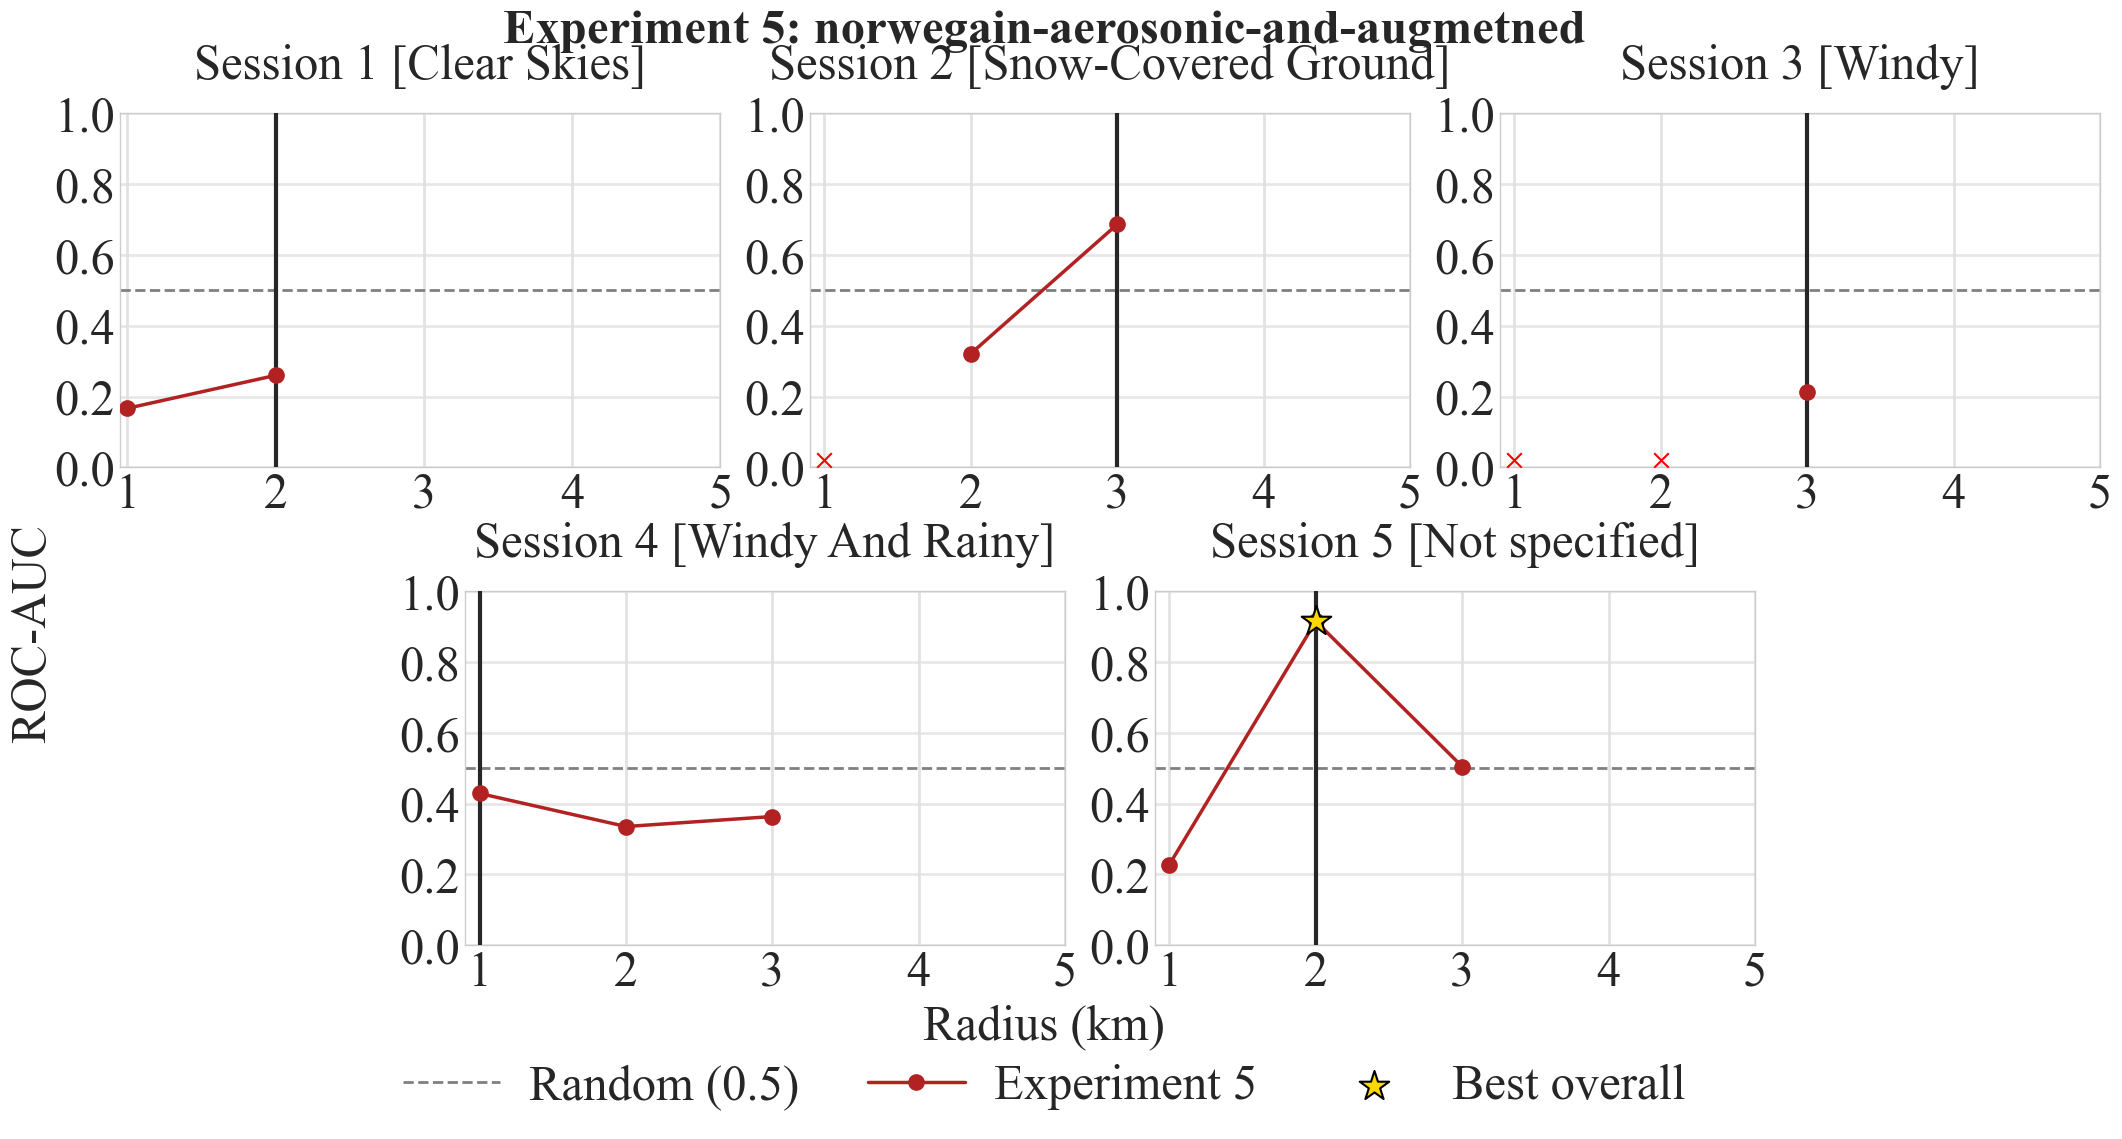

In [6]:
from matplotlib.lines import Line2D

session_id_to_weather = {
    1: "Clear Skies",
    2: "Snow-Covered Ground",
    3: "Windy",
    4: "Windy And Rainy",
    5: "Not specified",
}

EXPERIMENT_PLOT_STYLES = {
    "Experiment 2: radius_dual_norwegain_onlu-unfreeze-backbone": {
        "color": "steelblue",
        "marker": "o",
        "linestyle": "-",
    },
    "Experiment 3: aerosonic_to_norwegian_ex3": {
        "color": "darkorange",
        "marker": "o",
        "linestyle": "-",
    },
    "Experiment 4: norwegain-and-aerosonic": {
        "color": "seagreen",
        "marker": "o",
        "linestyle": "-",
    },
    "Experiment 5: norwegain-aerosonic-and-augmetned": {
        "color": "firebrick",
        "marker": "o",
        "linestyle": "-",
    },
}

def _session_subset(data: pd.DataFrame, session_id: int, experiment_name: str | None = None) -> pd.DataFrame:
    subset = data[data["session"] == session_id]
    if experiment_name is not None:
        subset = subset[subset["experiment"] == experiment_name]
    return subset.sort_values("radius_km")


def _extract_nested_value(payload: dict, candidate_paths: list[tuple[str, ...]]) -> float:
    for keys in candidate_paths:
        node = payload
        try:
            for key in keys:
                node = node[key]
            return float(node)
        except (KeyError, TypeError, ValueError):
            continue
    return np.nan


def _format_mean_std(mean_value: float, std_value: float, latex: bool = False) -> str:
    if pd.isna(mean_value):
        return "—"
    if pd.isna(std_value):
        return f"{mean_value:.4f}"
    separator = r" \pm " if latex else " ± "
    return f"{mean_value:.4f}{separator}{std_value:.4f}"


def _plot_radius_series(ax, session_data: pd.DataFrame, *, style: dict, label: str | None = None) -> bool:
    """Plot only contiguous radius segments so missing radii do not create connecting lines."""
    valid = session_data[~session_data["status"].eq("skipped") & session_data["roc_auc"].notna()].sort_values("radius_km")
    if valid.empty:
        return False

    plotted = False
    xs = valid["radius_km"].astype(float).to_numpy()
    start_idx = 0

    for idx in range(1, len(xs) + 1):
        is_break = idx == len(xs) or (xs[idx] - xs[idx - 1] > 1.000001)
        if not is_break:
            continue

        segment = valid.iloc[start_idx:idx]
        start_idx = idx
        if segment.empty:
            continue

        plot_label = label if not plotted else None
        line_kwargs = dict(
            marker=style["marker"],
            markersize=11,
            linewidth=2.5,
            color=style["color"],
            linestyle=style["linestyle"],
            zorder=20,
        )
        if len(segment) == 1:
            ax.plot(segment["radius_km"], segment["roc_auc"], linestyle="None", label=plot_label, **line_kwargs)
        else:
            ax.plot(segment["radius_km"], segment["roc_auc"], label=plot_label, **line_kwargs)
        plotted = True

    return plotted


def _display_roc_auc_table(data: pd.DataFrame, title: str, include_experiment: bool) -> None:
    table = data.copy()
    table["roc_auc"] = table["roc_auc"].round(4)

    if include_experiment:
        pivot = table.pivot_table(
            index=["experiment", "session"],
            columns="radius_km",
            values="roc_auc",
            aggfunc="first",
        )
    else:
        pivot = table.pivot_table(
            index="session",
            columns="radius_km",
            values="roc_auc",
            aggfunc="first",
        )

    pivot = pivot.reindex(columns=RADIUS_VALUES)
    display_table = pivot.copy()
    display_table.columns = [f"{radius} km" for radius in display_table.columns]

    best_radius = pivot.idxmax(axis=1)
    best_value = pivot.max(axis=1)
    display_table["Best radius"] = best_radius.map(lambda radius: f"{int(radius)} km" if pd.notna(radius) else "—")
    display_table["Best ROC-AUC"] = best_value.map(lambda value: f"{value:.4f}" if pd.notna(value) else "—")

    latex_table = display_table.to_latex(
        escape=False,
        na_rep="—",
        index=True,
    )

    print(title)
    display(display_table)
    print("LaTeX code:")
    print(latex_table)


def _display_metric_summary_table(data: pd.DataFrame, title: str) -> None:
    metric_specs = [
        ("roc_auc", "ROC-AUC"),
        ("precision", "Precision"),
        ("recall", "Recall"),
    ]
    display_rows = []
    latex_rows = []

    for metric_column, metric_label in metric_specs:
        display_row = {"Metric": metric_label}
        latex_row = {"Metric": metric_label}
        for radius_km in RADIUS_VALUES:
            radius_values = data.loc[data["radius_km"] == radius_km, metric_column].dropna()
            mean_value = radius_values.mean() if not radius_values.empty else np.nan
            std_value = radius_values.std(ddof=0) if not radius_values.empty else np.nan
            display_row[f"{radius_km} km"] = _format_mean_std(mean_value, std_value, latex=False)
            latex_row[f"{radius_km} km"] = _format_mean_std(mean_value, std_value, latex=True)
        display_rows.append(display_row)
        latex_rows.append(latex_row)

    display_table = pd.DataFrame(display_rows).set_index("Metric")
    latex_table = pd.DataFrame(latex_rows).set_index("Metric")
    latex_table = latex_table[[f"{radius_km} km" for radius_km in RADIUS_VALUES]]
    latex_code = latex_table.to_latex(escape=False, na_rep="—")

    print(title)
    display(display_table)
    print("LaTeX code:")
    print(latex_code)


def _display_best_radius_table(data: pd.DataFrame, title: str) -> None:
    best_rows = []
    latex_rows = []

    for session_id in sorted(data["session"].dropna().unique().tolist()):
        session_data = data[data["session"] == session_id].dropna(subset=["roc_auc"])
        if session_data.empty:
            best_rows.append({
                "Session": session_id,
                "Best Radius": "—",
                "Threshold": "—",
                "ROC-AUC": "—",
                "Precision": "—",
                "Recall": "—",
            })
            latex_rows.append({
                "Session": session_id,
                "Best Radius": "—",
                "Threshold": "—",
                "ROC-AUC": "—",
                "Precision": "—",
                "Recall": "—",
            })
            continue

        best_row = session_data.loc[session_data["roc_auc"].idxmax()]
        best_radius_label = f"{int(best_row['radius_km'])} km"
        threshold_value = best_row.get("threshold")
        row_display = {
            "Session": int(session_id),
            "Best Radius": best_radius_label,
            "Threshold": f"{threshold_value:.4f}" if pd.notna(threshold_value) else "—",
            "ROC-AUC": f"{best_row['roc_auc']:.4f}",
            "Precision": f"{best_row['precision']:.4f}" if pd.notna(best_row.get("precision")) else "—",
            "Recall": f"{best_row['recall']:.4f}" if pd.notna(best_row.get("recall")) else "—",
        }
        row_latex = {
            "Session": int(session_id),
            "Best Radius": best_radius_label,
            "Threshold": f"{threshold_value:.4f}" if pd.notna(threshold_value) else "—",
            "ROC-AUC": f"{best_row['roc_auc']:.4f}",
            "Precision": f"{best_row['precision']:.4f}" if pd.notna(best_row.get("precision")) else "—",
            "Recall": f"{best_row['recall']:.4f}" if pd.notna(best_row.get("recall")) else "—",
        }
        best_rows.append(row_display)
        latex_rows.append(row_latex)

    display_table = pd.DataFrame(best_rows).set_index("Session")
    latex_table = pd.DataFrame(latex_rows).set_index("Session")
    latex_code = latex_table.to_latex(escape=False, na_rep="—")

    print(title)
    display(display_table)
    print("LaTeX code:")
    print(latex_code)


def _display_session_radius_table(data: pd.DataFrame, title: str) -> None:
    session_radius = data.pivot_table(
        index="session",
        columns="radius_km",
        values="roc_auc",
        aggfunc="first",
    ).reindex(columns=RADIUS_VALUES)
    display_table = session_radius.copy()
    display_table.columns = [f"{radius} km" for radius in display_table.columns]
    display_table.index.name = "Session"
    display_table = display_table.map(lambda value: f"{value:.4f}" if pd.notna(value) else "—")
    latex_code = display_table.to_latex(escape=False, na_rep="—")

    print(title)
    display(display_table)
    print("LaTeX code:")
    print(latex_code)


def load_experiment(experiment_name: str, spec: dict) -> pd.DataFrame:
    rows = []

    for radius_km in RADIUS_VALUES:
        radius_dir = spec["radius_dirs"][radius_km]
        fold_root = radius_dir / spec["fold_leaf_dir"]

        for fold_id in FOLD_IDS:
            fold_dir = fold_root / f"fold_{fold_id}_test_{fold_id}"
            session_id = fold_to_session[fold_id]  # Map fold_id to session_id

            # metric file (various possible files)
            metric_file = find_metric_file(fold_dir)
            if metric_file is not None:
                payload = json.loads(metric_file.read_text(encoding="utf-8"))
                metric_values = {
                    "roc_auc": np.nan,
                    "precision": np.nan,
                    "recall": np.nan,
                }
                metric_paths = {
                    "roc_auc": [
                        ("metrics", "auc"),
                        ("training_result", "test_metrics", "auc"),
                        ("result", "metrics", "auc"),
                        ("test_metrics", "auc"),
                    ],
                    "precision": [
                        ("metrics", "precision"),
                        ("training_result", "test_metrics", "precision"),
                        ("result", "metrics", "precision"),
                        ("test_metrics", "precision"),
                    ],
                    "recall": [
                        ("metrics", "recall"),
                        ("training_result", "test_metrics", "recall"),
                        ("result", "metrics", "recall"),
                        ("test_metrics", "recall"),
                    ],
                }

                for metric_name, candidate_paths in metric_paths.items():
                    metric_values[metric_name] = _extract_nested_value(payload, candidate_paths)

                auc = metric_values["roc_auc"]
                precision = metric_values["precision"]
                recall = metric_values["recall"]
            else:
                auc = np.nan
                precision = np.nan
                recall = np.nan

            threshold = np.nan
            threshold_path = fold_dir / "single_fold_result.json"
            if threshold_path.exists():
                try:
                    threshold_payload = json.loads(threshold_path.read_text(encoding="utf-8"))
                    threshold = _extract_nested_value(
                        threshold_payload,
                        [
                            ("result", "best_threshold (used for metrics in test)"),
                            ("best_threshold (used for metrics in test)",),
                        ],
                    )
                except Exception:
                    threshold = np.nan

            # extract fold status from fold_summary.json if present
            status = None
            summary_path = fold_dir / "fold_summary.json"
            if summary_path.exists():
                try:
                    summary = json.loads(summary_path.read_text(encoding="utf-8"))
                    status = summary.get("status") or summary.get("result", {}).get("status")
                except Exception:
                    status = None

            rows.append({
                "experiment": experiment_name,
                "session": session_id,
                "radius_km": radius_km,
                "roc_auc": auc,
                "precision": precision,
                "recall": recall,
                "threshold": threshold,
                "status": status,
                "metric_file": str(metric_file) if metric_file is not None else None,
                "fold_dir": str(fold_dir),
            })

    return pd.DataFrame(rows)


all_results = pd.concat(
    [load_experiment(name, spec) for name, spec in EXPERIMENTS.items()],
    ignore_index=True,
)

display(all_results.sort_values(["experiment", "session", "radius_km"]))

def plot_experiment_results(experiment_name: str, data: pd.DataFrame) -> None:
    _display_metric_summary_table(data, f"Metric summary table for {experiment_name}")
    _display_best_radius_table(data, f"Best-radius table for {experiment_name}")
    _display_session_radius_table(data, f"Session-by-radius ROC-AUC table for {experiment_name}")
    style = EXPERIMENT_PLOT_STYLES[experiment_name]
    fig = plt.figure(figsize=(22, 13))
    grid = fig.add_gridspec(2, 6, hspace=0.35, wspace=0.35)
    axes = [
        fig.add_subplot(grid[0, 0:2]),
        fig.add_subplot(grid[0, 2:4]),
        fig.add_subplot(grid[0, 4:6]),
        fig.add_subplot(grid[1, 1:3]),
        fig.add_subplot(grid[1, 3:5]),
    ]
    suptitle = fig.suptitle(experiment_name, fontsize=TITLE_FONT_SIZE, fontweight="bold")

    legend_added = {
        "valid": False,
        "skipped": False,
        "missing": False,
        "random": False,
        "best": False,
        "global_best": False,
    }
    session_ids = sorted([fold_to_session[fold_id] for fold_id in FOLD_IDS])
    pdf_dir = Path("outputs") / "experiment_radius_roc_auc_panels"
    pdf_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = pdf_dir / f"{experiment_name.replace(':', '').replace(' ', '_').replace('/', '_')}.pdf"

    global_best_candidates = data[data["roc_auc"].notna() & ~data["status"].eq("skipped")]
    global_best_row = global_best_candidates.loc[global_best_candidates["roc_auc"].idxmax()] if not global_best_candidates.empty else None

    for axis, session_id in zip(axes, session_ids):
        session_data = _session_subset(data, session_id)
        axis.set_axisbelow(True)

        valid = session_data[~session_data["status"].eq("skipped") & session_data["roc_auc"].notna()]
        skipped = session_data[session_data["status"].eq("skipped")]
        missing = session_data[session_data["roc_auc"].isna() & ~session_data["status"].eq("skipped")]
        print(f"Session {session_id} - valid rows: {len(valid)}, skipped rows: {len(skipped)}, missing rows: {len(missing)}")

        axis.axhline(
            0.5,
            color="gray",
            linestyle="--",
            linewidth=2,
            alpha=1,
            label=("Random (0.5)" if not legend_added['random'] else None),
            zorder=1,
        )
        legend_added['random'] = True

        axis.grid(True, axis="x", color="0.85", linestyle="-", linewidth=2, alpha=0.75)
        axis.grid(True, axis="y", color="0.88", linestyle="-", linewidth=2, alpha=0.75)

        best_candidates = session_data[session_data["roc_auc"].notna()]
        if not best_candidates.empty:
            best_row = best_candidates.loc[best_candidates["roc_auc"].idxmax()]
            axis.axvline(
                best_row["radius_km"],
                color="0.15",
                linestyle="-",
                linewidth=3.0,
                alpha=1.0,
                zorder=10,
            )
            legend_added['best'] = True

        if global_best_row is not None and session_id == global_best_row["session"]:
            axis.scatter(
                [global_best_row["radius_km"]],
                [global_best_row["roc_auc"]],
                marker="*",
                s=500,
                color="gold",
                edgecolors="black",
                linewidths=1.5,
                label=("Best overall" if not legend_added['global_best'] else None),
                zorder=30,
            )
            legend_added['global_best'] = True

        if not valid.empty:
            plot_series = (
            session_data
            .set_index("radius_km")
            .reindex(RADIUS_VALUES)["roc_auc"]
        )
            axis.plot(
                RADIUS_VALUES,
                plot_series,
                marker=style["marker"],
                markersize=11,
                linewidth=2.5,
                color=style["color"],
                linestyle=style["linestyle"],
                label=experiment_name.split(":")[0],
                zorder=20,
            )
            """ axis.plot(
                valid["radius_km"],
                valid["roc_auc"],
                marker="o",
                markersize=11,
                linewidth=2.2,
                color=style["color"],
                label=("Valid" if not legend_added['valid'] else None),
                zorder=20,
            ) """
            legend_added['valid'] = True

        if not skipped.empty:
            skipped_y = skipped["roc_auc"].copy().fillna(0.02)
            axis.scatter(
                skipped["radius_km"],
                skipped_y,
                marker="x",
                color="red",
                s=110,
                zorder=4,
            )
            legend_added['skipped'] = True

        """ if not missing.empty:
            missed_y = missing["roc_auc"].copy().fillna(0.02)
            axis.scatter(
                missing["radius_km"],
                missed_y,
                marker="o",
                facecolors="none",
                edgecolors="red",
                s=95,
                label=("Missing" if not legend_added['missing'] else None),
                zorder=2,
            )
            legend_added['missing'] = True """

        axis.set_title(f"Session {session_id} [{session_id_to_weather[session_id]}]", pad=25)
        axis.set_xticks(RADIUS_VALUES)
        axis.set_xlabel("")
        axis.set_ylabel("")
        axis.set_ylim(0.0, 1.0)
        axis.set_yticks(np.arange(0.0, 1.01, 0.2))

    fig.supxlabel("Radius (km)", fontsize=LABEL_FONT_SIZE, y=0.18)
    fig.supylabel("ROC-AUC", fontsize=LABEL_FONT_SIZE, x=0.03)

    handles = []
    labels = []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                labels.append(ll)
                handles.append(hh)

    number_of_handles = len(handles)
    if number_of_handles == 3:
        ncol = 3
    else: 
        ncol = 4

    if labels:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.10),
            ncol=ncol,
            columnspacing=1.4,
            handletextpad=0.6,
            fontsize=LEGEND_FONT_SIZE,
        )

    fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.26)

    if suptitle is not None:
        suptitle.set_visible(False)
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    if suptitle is not None:
        suptitle.set_visible(True)

    display(FileLink(str(pdf_path)))
    plt.show()


def plot_merged_experiment_results(data: pd.DataFrame) -> None:
    _display_roc_auc_table(data, "ROC-AUC table for merged comparison", include_experiment=True)
    experiment_names = list(EXPERIMENT_PLOT_STYLES.keys())
    fig = plt.figure(figsize=(24, 20))
    grid = fig.add_gridspec(2, 6, hspace=0.35, wspace=0.35)
    axes = [
        fig.add_subplot(grid[0, 0:2]),
        fig.add_subplot(grid[0, 2:4]),
        fig.add_subplot(grid[0, 4:6]),
        fig.add_subplot(grid[1, 1:3]),
        fig.add_subplot(grid[1, 3:5]),
    ]
    suptitle = fig.suptitle("Merged comparison across experiments", fontsize=TITLE_FONT_SIZE, fontweight="bold")
    pdf_dir = Path("outputs") / "experiment_radius_roc_auc_panels"
    pdf_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = pdf_dir / "merged_experiment_comparison.pdf"

    global_best_candidates = data[data["roc_auc"].notna() & ~data["status"].eq("skipped")]
    global_best_row = global_best_candidates.loc[global_best_candidates["roc_auc"].idxmax()] if not global_best_candidates.empty else None

    for axis, session_id in zip(axes, sorted([fold_to_session[fold_id] for fold_id in FOLD_IDS])):
        axis.set_axisbelow(True)
        axis.axhline(0.5, color="gray", linestyle="--", linewidth=2, alpha=1, zorder=1)
        axis.grid(True, axis="x", color="0.85", linestyle="-", linewidth=2, alpha=0.75)
        axis.grid(True, axis="y", color="0.88", linestyle="-", linewidth=2, alpha=0.75)

        session_best = _session_subset(data, session_id)

        for experiment_name in experiment_names:
            style = EXPERIMENT_PLOT_STYLES[experiment_name]
            session_data = _session_subset(data, session_id, experiment_name)
            valid = session_data[~session_data["status"].eq("skipped") & session_data["roc_auc"].notna()]
            skipped = session_data[session_data["status"].eq("skipped")]
            missing = session_data[session_data["roc_auc"].isna() & ~session_data["status"].eq("skipped")]
            short_label = experiment_name.split(":")[0]

            if not valid.empty:
                plot_series = (
                session_data
                .set_index("radius_km")
                .reindex(RADIUS_VALUES)["roc_auc"]
                )

                axis.plot(
                    RADIUS_VALUES,
                    plot_series,
                    marker=style["marker"],
                    markersize=11,
                    linewidth=2.5,
                    color=style["color"],
                    linestyle=style["linestyle"],
                    label=experiment_name.split(":")[0],
                    zorder=20,
                )

            if not skipped.empty:
                skipped_y = skipped["roc_auc"].copy().fillna(0.02)
                axis.scatter(
                    skipped["radius_km"],
                    skipped_y,
                    marker="x",
                    color=style["color"],
                    s=110,
                    zorder=4,
                )

            """ if not missing.empty:
                missed_y = missing["roc_auc"].copy().fillna(0.02)
                axis.scatter(
                    missing["radius_km"],
                    missed_y,
                    marker="o",
                    facecolors="none",
                    edgecolors=style["color"],
                    s=95,
                    zorder=2,
                ) """

        if global_best_row is not None and session_id == global_best_row["session"]:
            axis.scatter(
                [global_best_row["radius_km"]],
                [global_best_row["roc_auc"]],
                marker="*",
                s=500,
                color="gold",
                edgecolors="black",
                linewidths=1.5,
                label="Best overall",
                zorder=30,
            )

        if not session_best.empty:
            best_row = session_best.loc[session_best["roc_auc"].idxmax()]
            axis.axvline(best_row["radius_km"], color="0.15", linestyle="-", linewidth=3.0, alpha=1.0, zorder=10)

        axis.set_title(f"Session {session_id} [{session_id_to_weather[session_id]}]", pad=25)
        axis.set_xticks(RADIUS_VALUES)
        axis.set_xlabel("")
        axis.set_ylabel("")
        axis.set_ylim(0.0, 1.0)
        axis.set_yticks(np.arange(0.0, 1.01, 0.2))

    fig.supxlabel("Radius (km)", fontsize=LABEL_FONT_SIZE, y=0.20)
    fig.supylabel("ROC-AUC", fontsize=LABEL_FONT_SIZE, x=0.03)

    legend_handles = [
        Line2D([0], [0], color=EXPERIMENT_PLOT_STYLES[name]["color"], marker=EXPERIMENT_PLOT_STYLES[name]["marker"], linewidth=2.5, label=EXPERIMENT_TO_TITLE[name.split(":")[0]])
        for name in experiment_names
    ]
    legend_handles.extend([
        Line2D([0], [0], color="gray", linestyle="--", linewidth=2, label="Random (0.5)"),
        Line2D([0], [0], color="red", marker="x", linestyle="None", label="Skipped"),
        # Line2D([0], [0], color="gray", marker="o", linestyle="None", markerfacecolor="none", label="Missing"),
        Line2D([0], [0], color="gold", marker="*", linestyle="None", markersize=16, markeredgecolor="black", label="Best overall"),
    ])
    ncol = 2
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.035),
        ncol=ncol,
        columnspacing=1.2,
        handletextpad=0.6,
        fontsize=LEGEND_FONT_SIZE,
    )

    fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.26)

    if suptitle is not None:
        suptitle.set_visible(False)
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    if suptitle is not None:
        suptitle.set_visible(True)

    display(FileLink(str(pdf_path)))
    plt.show()

plot_merged_experiment_results(all_results)


for experiment_name in EXPERIMENTS:
    experiment_data = all_results[all_results["experiment"] == experiment_name]
    plot_experiment_results(experiment_name, experiment_data)

#experiement_2_and_3 = all_results[all_results["experiment"].isin(["Experiment 2: radius_dual_norwegain_onlu-unfreeze-backbone", "Experiment 3: aerosonic_to_norwegian_ex3"])]
